<center><h1>Lanka_VenkataSriSaiPavani_HW5</h1></center>
<br>
<br>

Name: Venkata Sri Sai Pavani Lanka
<br>
Github Username: lanka1908
<br>
USC ID: 4885549248

## 1. Decision Trees as Interpretable Models

Import packages

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from skmultilearn.problem_transform import LabelPowerset
from sklearn.tree import _tree
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

### (a) Obtain Data

Get the Accute Inamations Data Set

In [8]:
data_dir = '../data/acute_inflammations/diagnosis.data'
acute_df = pd.read_csv(data_dir, header=None, encoding='utf-16', delimiter="\t")
acute_df.columns = ['Temperature', 'Nausea', 'Lumbar Pain', 'Urine Pushing', 'Micturition Pains', 'Burning of Urethra', 'Inflammation', 'Nephritis']
acute_df.head()

,Temperature,Nausea,Lumbar Pain,Urine Pushing,Micturition Pains,Burning of Urethra,Inflammation,Nephritis
0,"35,5",no,yes,no,no,no,no,no
1,"35,9",no,no,yes,yes,yes,yes,no
2,"35,9",no,yes,no,no,no,no,no
3,"36,0",no,no,yes,yes,yes,yes,no
4,"36,0",no,yes,no,no,no,no,no


### (b) Build a decision tree

C:\Users\saipa\AppData\Local\Temp\ipykernel_15828\1908797115.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  acute_df = acute_df.replace({'yes': 1, 'no': 0})


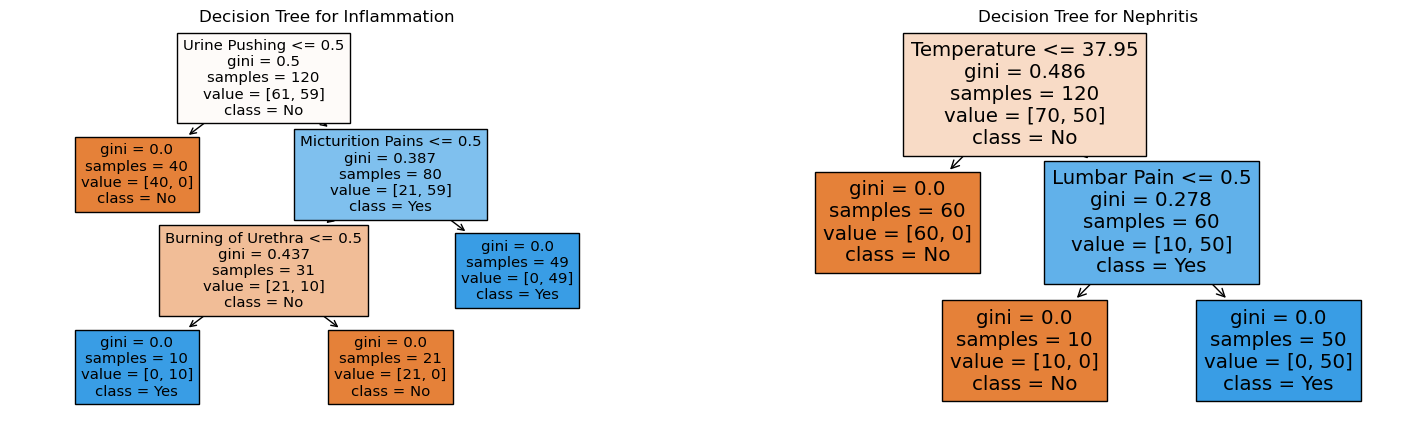

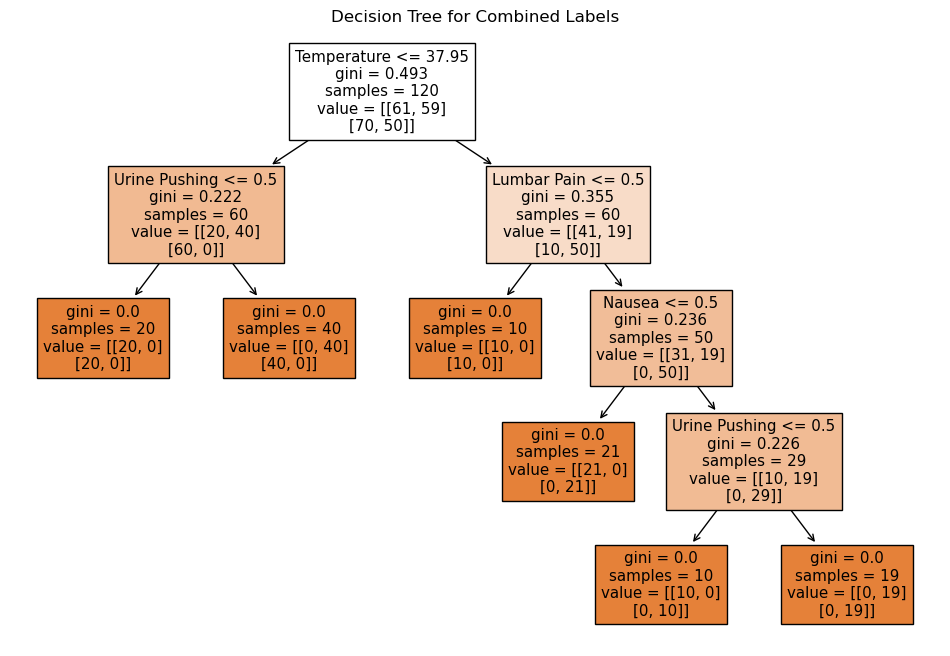

In [10]:
# Site Reference
acute_df = acute_df.replace({'yes': 1, 'no': 0})
acute_df = acute_df.replace(',', '.', regex=True)

X = acute_df.iloc[:, :-2]
y = acute_df.iloc[:, -2:]

X = X.apply(pd.to_numeric)
y = y.apply(pd.to_numeric)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

for i, label in enumerate(y.columns):
    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X, y[label])
    
    plot_tree(clf, filled=True, ax=axes[i], feature_names=X.columns, class_names=['No', 'Yes'])
    axes[i].set_title(f"Decision Tree for {label}")

y_combined = acute_df[['Inflammation','Nephritis']]
clf_combined = DecisionTreeClassifier(random_state=42)
clf_combined.fit(X, y_combined)

plt.figure(figsize=(12, 8))
plot_tree(clf_combined, filled=True, feature_names=X.columns, class_names=['No Inflammation', 'Inflammation', 'No Nephritis', 'Nephritis'])
plt.title("Decision Tree for Combined Labels")
plt.show()

### (c) Convert the decision rules

In [12]:
# Site Reference

def tree_to_code(tree, feature_names, target_names):
    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
        for i in tree_.feature
    ]
    print(f"def decision_tree({', '.join(feature_names)}):")

    def recurse(node, depth):
        indent = "  " * depth
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = feature_name[node]
            threshold = tree_.threshold[node]
            print(f"{indent}if {name} <= {threshold:.6f}:")
            recurse(tree_.children_left[node], depth + 1)
            print(f"{indent}else:  # if {name} > {threshold:.6f}")
            recurse(tree_.children_right[node], depth + 1)
        else:
            raw_counts = tree_.value[node][0]
            total_samples = tree_.weighted_n_node_samples[node] if hasattr(tree_, 'weighted_n_node_samples') else tree_.n_node_samples[node]
            weighted_counts = raw_counts * total_samples
            available_classes = len(raw_counts)
            class_counts = {target_names[i]: weighted_counts[i] for i in range(available_classes)}
            probabilities = {target_names[i]: round(weighted_counts[i] / total_samples, 2) for i in range(available_classes)}
            predicted_label_index = np.argmax(weighted_counts)
            
            print(f"{indent}Counts: {class_counts}")
            print(f"{indent}Probabilities: {probabilities}")
            print(f"{indent}return '{target_names[predicted_label_index]}'")

    recurse(0, 1)

for i, label in enumerate(y.columns):
    print(f"\nDecision Rules for {label}:")
    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X, y[label])
    tree_to_code(clf, X.columns, ['No', 'Yes'])
    print("\n" + "="*50 + "\n")

combined_target_names = ["No Inflammation", "Inflammation", "No Nephritis", "Nephritis"]

print("Decision Rules for Combined Labels (Label Powerset):")
tree_to_code(clf_combined, X.columns, combined_target_names)


Decision Rules for Inflammation:
def decision_tree(Temperature, Nausea, Lumbar Pain, Urine Pushing, Micturition Pains, Burning of Urethra):
  if Urine Pushing <= 0.500000:
    Counts: {'No': 40.0, 'Yes': 0.0}
    Probabilities: {'No': 1.0, 'Yes': 0.0}
    return 'No'
  else:  # if Urine Pushing > 0.500000
    if Micturition Pains <= 0.500000:
      if Burning of Urethra <= 0.500000:
        Counts: {'No': 0.0, 'Yes': 10.0}
        Probabilities: {'No': 0.0, 'Yes': 1.0}
        return 'Yes'
      else:  # if Burning of Urethra > 0.500000
        Counts: {'No': 21.0, 'Yes': 0.0}
        Probabilities: {'No': 1.0, 'Yes': 0.0}
        return 'No'
    else:  # if Micturition Pains > 0.500000
      Counts: {'No': 0.0, 'Yes': 49.0}
      Probabilities: {'No': 0.0, 'Yes': 1.0}
      return 'Yes'



Decision Rules for Nephritis:
def decision_tree(Temperature, Nausea, Lumbar Pain, Urine Pushing, Micturition Pains, Burning of Urethra):
  if Temperature <= 37.950001:
    Counts: {'No': 60.0, 'Yes

### 1.4. (d) Cost-complexity pruning


Pruned Tree for Inflammation:
Selected alpha for Inflammation: 0.1452217741935484


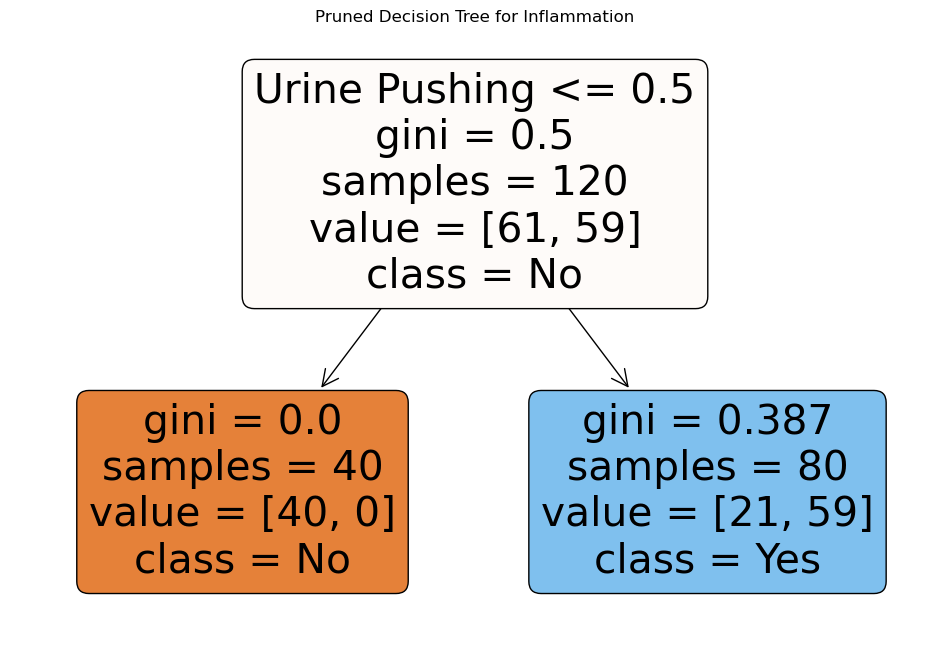


Decision Rules for Pruned Inflammation:
def decision_tree(Temperature, Nausea, Lumbar Pain, Urine Pushing, Micturition Pains, Burning of Urethra):
  if Urine Pushing <= 0.500000:
    Counts: {'No': 40.0, 'Yes': 0.0}
    Probabilities: {'No': 1.0, 'Yes': 0.0}
    return 'No'
  else:  # if Urine Pushing > 0.500000
    Counts: {'No': 21.0, 'Yes': 59.0}
    Probabilities: {'No': 0.26, 'Yes': 0.74}
    return 'Yes'



Pruned Tree for Nephritis:
Selected alpha for Nephritis: 0.1388888888888889


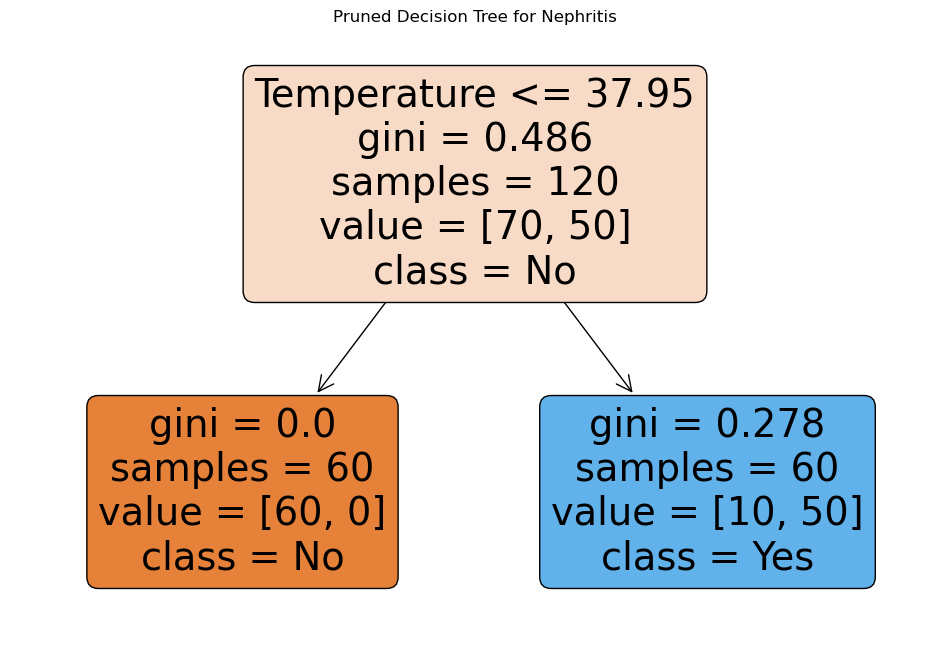


Decision Rules for Pruned Nephritis:
def decision_tree(Temperature, Nausea, Lumbar Pain, Urine Pushing, Micturition Pains, Burning of Urethra):
  if Temperature <= 37.950001:
    Counts: {'No': 60.0, 'Yes': 0.0}
    Probabilities: {'No': 1.0, 'Yes': 0.0}
    return 'No'
  else:  # if Temperature > 37.950001
    Counts: {'No': 10.0, 'Yes': 50.0}
    Probabilities: {'No': 0.17, 'Yes': 0.83}
    return 'Yes'


Pruned Tree for Combined Labels (Label Powerset):
Selected alpha for combined labels: 0.04908333333333333


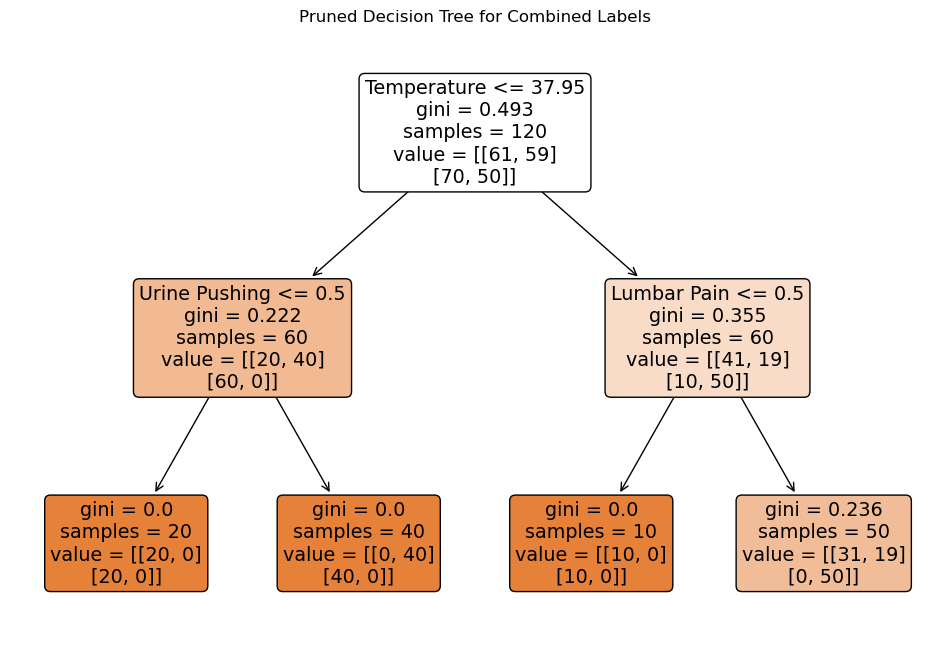


Decision Rules for Pruned Combined Labels:
def decision_tree(Temperature, Nausea, Lumbar Pain, Urine Pushing, Micturition Pains, Burning of Urethra):
  if Temperature <= 37.950001:
    if Urine Pushing <= 0.500000:
      Counts: {'No Inflammation': 20.0, 'Inflammation': 0.0}
      Probabilities: {'No Inflammation': 1.0, 'Inflammation': 0.0}
      return 'No Inflammation'
    else:  # if Urine Pushing > 0.500000
      Counts: {'No Inflammation': 0.0, 'Inflammation': 40.0}
      Probabilities: {'No Inflammation': 0.0, 'Inflammation': 1.0}
      return 'Inflammation'
  else:  # if Temperature > 37.950001
    if Lumbar Pain <= 0.500000:
      Counts: {'No Inflammation': 10.0, 'Inflammation': 0.0}
      Probabilities: {'No Inflammation': 1.0, 'Inflammation': 0.0}
      return 'No Inflammation'
    else:  # if Lumbar Pain > 0.500000
      Counts: {'No Inflammation': 31.0, 'Inflammation': 19.0}
      Probabilities: {'No Inflammation': 0.62, 'Inflammation': 0.38}
      return 'No Inflammation

In [14]:
# Chatgpt reference

def get_best_alpha(X, y):
    clf = DecisionTreeClassifier(random_state=42)
    path = clf.cost_complexity_pruning_path(X, y)
    ccp_alphas = path.ccp_alphas

    best_ccp_alpha = ccp_alphas[-2] if len(ccp_alphas) > 1 else ccp_alphas[0]
    return best_ccp_alpha

def get_smallest_nonzero_alpha(X, y):
    clf = DecisionTreeClassifier(random_state=42)
    path = clf.cost_complexity_pruning_path(X, y)
    ccp_alphas = path.ccp_alphas

    smallest_nonzero_alpha = next(alpha for alpha in ccp_alphas if alpha > 0)
    return smallest_nonzero_alpha

for i, label in enumerate(y.columns):
    print(f"\nPruned Tree for {label}:")

    best_alpha = get_best_alpha(X, y[label])
    print(f"Selected alpha for {label}: {best_alpha}")
    pruned_clf = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
    pruned_clf.fit(X, y[label])
    
    plt.figure(figsize=(12, 8))
    plot_tree(pruned_clf, filled=True, feature_names=X.columns, class_names=['No', 'Yes'], rounded=True)
    plt.title(f"Pruned Decision Tree for {label}")
    plt.show()
    
    print(f"\nDecision Rules for Pruned {label}:")
    tree_to_code(pruned_clf, X.columns, ['No', 'Yes'])
    print("\n" + "="*50 + "\n")

print("Pruned Tree for Combined Labels (Label Powerset):")

combined_best_alpha = get_smallest_nonzero_alpha(X, y[['Inflammation', 'Nephritis']])
print(f"Selected alpha for combined labels: {combined_best_alpha}")
pruned_combined_clf = DecisionTreeClassifier(random_state=42, ccp_alpha=combined_best_alpha)
pruned_combined_clf.fit(X, y[['Inflammation', 'Nephritis']])

plt.figure(figsize=(12, 8))
plot_tree(pruned_combined_clf, filled=True, feature_names=X.columns, class_names=["No Inflammation", "Inflammation", "No Nephritis", "Nephritis"], rounded=True)
plt.title("Pruned Decision Tree for Combined Labels")
plt.show()

print("\nDecision Rules for Pruned Combined Labels:")
tree_to_code(pruned_combined_clf, X.columns, ["No Inflammation", "Inflammation", "No Nephritis", "Nephritis"])

## 2. The LASSO and Boosting for Regression

### (a) Obtain Data

In [17]:
file_path = '../data/acute_inflammations/communities.csv'
column_names = ['state', 'county', 'community', 'communityname', 'fold', 'population', 'householdsize', 'racepctblack', 'racePctWhite', 'racePctAsian', 'racePctHisp', 'agePct12t21', 'agePct12t29', 'agePct16t24', 'agePct65up', 'numbUrban', 'pctUrban', 'medIncome', 'pctWWage', 'pctWFarmSelf', 'pctWInvInc', 'pctWSocSec', 'pctWPubAsst', 'pctWRetire', 'medFamInc', 'perCapInc', 'whitePerCap', 'blackPerCap', 'indianPerCap', 'AsianPerCap', 'OtherPerCap', 'HispPerCap', 'NumUnderPov', 'PctPopUnderPov', 'PctLess9thGrade', 'PctNotHSGrad', 'PctBSorMore', 'PctUnemployed', 'PctEmploy', 'PctEmplManu', 'PctEmplProfServ', 'PctOccupManu', 'PctOccupMgmtProf', 'MalePctDivorce', 'MalePctNevMarr', 'FemalePctDiv', 'TotalPctDiv', 'PersPerFam', 'PctFam2Par', 'PctKids2Par', 'PctYoungKids2Par', 'PctTeen2Par', 'PctWorkMomYoungKids', 'PctWorkMom', 'NumIlleg', 'PctIlleg', 'NumImmig', 'PctImmigRecent', 'PctImmigRec5', 'PctImmigRec8', 'PctImmigRec10', 'PctRecentImmig', 'PctRecImmig5', 'PctRecImmig8', 'PctRecImmig10', 'PctSpeakEnglOnly', 'PctNotSpeakEnglWell', 'PctLargHouseFam', 
                'PctLargHouseOccup', 'PersPerOccupHous', 'PersPerOwnOccHous', 'PersPerRentOccHous', 'PctPersOwnOccup', 'PctPersDenseHous', 'PctHousLess3BR', 'MedNumBR', 'HousVacant', 'PctHousOccup', 'PctHousOwnOcc', 'PctVacantBoarded', 'PctVacMore6Mos', 'MedYrHousBuilt', 'PctHousNoPhone', 'PctWOFullPlumb', 'OwnOccLowQuart', 'OwnOccMedVal', 'OwnOccHiQuart', 'RentLowQ', 'RentMedian', 'RentHighQ', 'MedRent', 'MedRentPctHousInc', 'MedOwnCostPctInc', 'MedOwnCostPctIncNoMtg', 'NumInShelters', 'NumStreet', 'PctForeignBorn', 'PctBornSameState', 'PctSameHouse85', 'PctSameCity85', 'PctSameState85', 'LemasSwornFT', 'LemasSwFTPerPop', 'LemasSwFTFieldOps', 'LemasSwFTFieldPerPop', 'LemasTotalReq', 'LemasTotReqPerPop', 'PolicReqPerOffic', 'PolicPerPop', 'RacialMatchCommPol', 'PctPolicWhite', 'PctPolicBlack', 'PctPolicHisp', 'PctPolicAsian', 'PctPolicMinor', 'OfficAssgnDrugUnits', 'NumKindsDrugsSeiz', 'PolicAveOTWorked', 'LandArea', 'PopDens', 'PctUsePubTrans', 'PolicCars', 'PolicOperBudg', 'LemasPctPolicOnPatr', 'LemasGangUnitDeploy', 'LemasPctOfficDrugUn', 'PolicBudgPerPop', 'ViolentCrimesPerPop']
communities_df = pd.read_csv(file_path, header=None, names=column_names)

train_df = communities_df.iloc[:1495, :]
test_df = communities_df.iloc[1495:, :]

print(train_df.shape)
print(test_df.shape)
communities_df.head()

(1495, 128)
(499, 128)


,state,county,community,communityname,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,...,LandArea,PopDens,PctUsePubTrans,PolicCars,PolicOperBudg,LemasPctPolicOnPatr,LemasGangUnitDeploy,LemasPctOfficDrugUn,PolicBudgPerPop,ViolentCrimesPerPop
0,8,?,?,Lakewoodcity,1,0.19,0.33,0.02,0.90,0.12,...,0.12,0.26,0.20,0.06,0.04,0.9,0.5,0.32,0.14,0.20
1,53,?,?,Tukwilacity,1,0.00,0.16,0.12,0.74,0.45,...,0.02,0.12,0.45,?,?,?,?,0.00,?,0.67
2,24,?,?,Aberdeentown,1,0.00,0.42,0.49,0.56,0.17,...,0.01,0.21,0.02,?,?,?,?,0.00,?,0.43
3,34,5,81440,Willingborotownship,1,0.04,0.77,1.00,0.08,0.12,...,0.02,0.39,0.28,?,?,?,?,0.00,?,0.12
4,42,95,6096,Bethlehemtownship,1,0.01,0.55,0.02,0.95,0.09,...,0.04,0.09,0.02,?,?,?,?,0.00,?,0.03


### (b) Missing values

In [19]:
#Site reference
non_predictive_features = ['state', 'county', 'community', 'communityname', 'fold']
communities_df = communities_df.drop(columns=non_predictive_features)

#Took this part of checking non-numeric columns code from chatgpt
non_numeric_cols = communities_df.select_dtypes(exclude=['number']).columns

for col in non_numeric_cols:
    communities_df[col] = pd.to_numeric(communities_df[col], errors='coerce')

train_df = communities_df.iloc[:1495, :]
test_df = communities_df.iloc[1495:, :]

train_df = train_df.fillna(train_df.mean())
test_df = test_df.fillna(test_df.mean())

print("Remaining NaN values:", train_df.isnull().sum().sum())
print("Remaining NaN values:", test_df.isnull().sum().sum())

Remaining NaN values: 0
Remaining NaN values: 0


### (c) Plot a correlation matrix

                     population  householdsize  racepctblack  racePctWhite  \
population             1.000000      -0.046148      0.231178     -0.300845   
householdsize         -0.046148       1.000000     -0.067109     -0.235907   
racepctblack           0.231178      -0.067109      1.000000     -0.794389   
racePctWhite          -0.300845      -0.235907     -0.794389      1.000000   
racePctAsian           0.181603       0.201996     -0.106738     -0.270266   
...                         ...            ...           ...           ...   
LemasPctPolicOnPatr   -0.080482      -0.017972     -0.168434      0.125223   
LemasGangUnitDeploy    0.100012      -0.000784      0.022388     -0.078552   
LemasPctOfficDrugUn    0.466352      -0.094368      0.260793     -0.276234   
PolicBudgPerPop       -0.046494      -0.152603      0.045311     -0.014957   
ViolentCrimesPerPop    0.367157      -0.034923      0.631264     -0.684770   

                     racePctAsian  racePctHisp  agePct12t21  ag

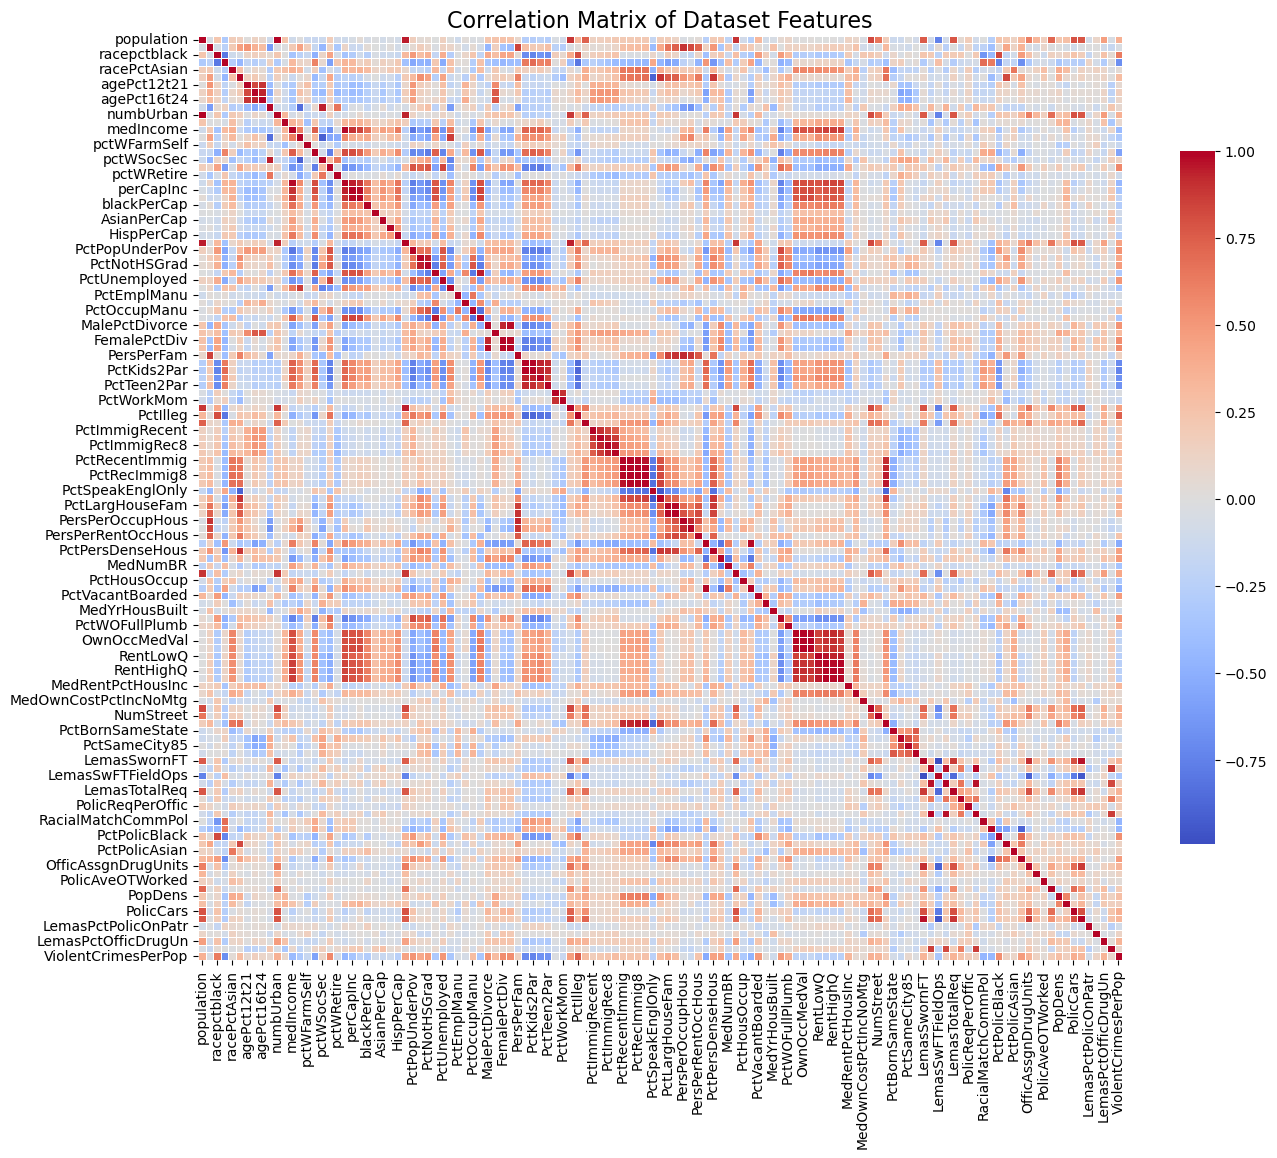

In [21]:
#Site reference

correlation_matrix = communities_df.corr()
print(correlation_matrix)
plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=.5, cbar_kws={"shrink": .75})

plt.title("Correlation Matrix of Dataset Features", fontsize=16)
plt.show()

### (d) Calculate the Coefficient of Variation CV

In [23]:
means_train = train_df.mean()
std_devs_train = train_df.std()

cv_train = std_devs_train / means_train

cv_train_df = pd.DataFrame(cv_train, columns=['Coefficient of Variation'])
print("Coefficient of Variations of the train set:")
print(cv_train_df)

means_test = test_df.mean()
std_devs_test = test_df.std()

cv_test = std_devs_test / means_test

cv_test_df = pd.DataFrame(cv_test, columns=['Coefficient of Variation'])
print("Coefficient of Variations of the test set:")
print(cv_test_df)

means_combined = communities_df.mean()
std_devs_combined = communities_df.std()

cv = std_devs_combined / means_combined

cv_df = pd.DataFrame(cv, columns=['Coefficient of Variation'])
print("Coefficient of Variations of the whole dataset:")
print(cv_df)

Coefficient of Variations of the train set:
                     Coefficient of Variation
population                           2.241105
householdsize                        0.355800
racepctblack                         1.428885
racePctWhite                         0.330213
racePctAsian                         1.359100
...                                       ...
LemasPctPolicOnPatr                  0.115739
LemasGangUnitDeploy                  0.362989
LemasPctOfficDrugUn                  2.552946
PolicBudgPerPop                      0.326026
ViolentCrimesPerPop                  0.987909

[123 rows x 1 columns]
Coefficient of Variations of the test set:
                     Coefficient of Variation
population                           2.077145
householdsize                        0.346017
racepctblack                         1.356525
racePctWhite                         0.304182
racePctAsian                         1.360714
...                                       ...
LemasPctPolicOn

### (e) Scatter plots and box plots for highest CV features

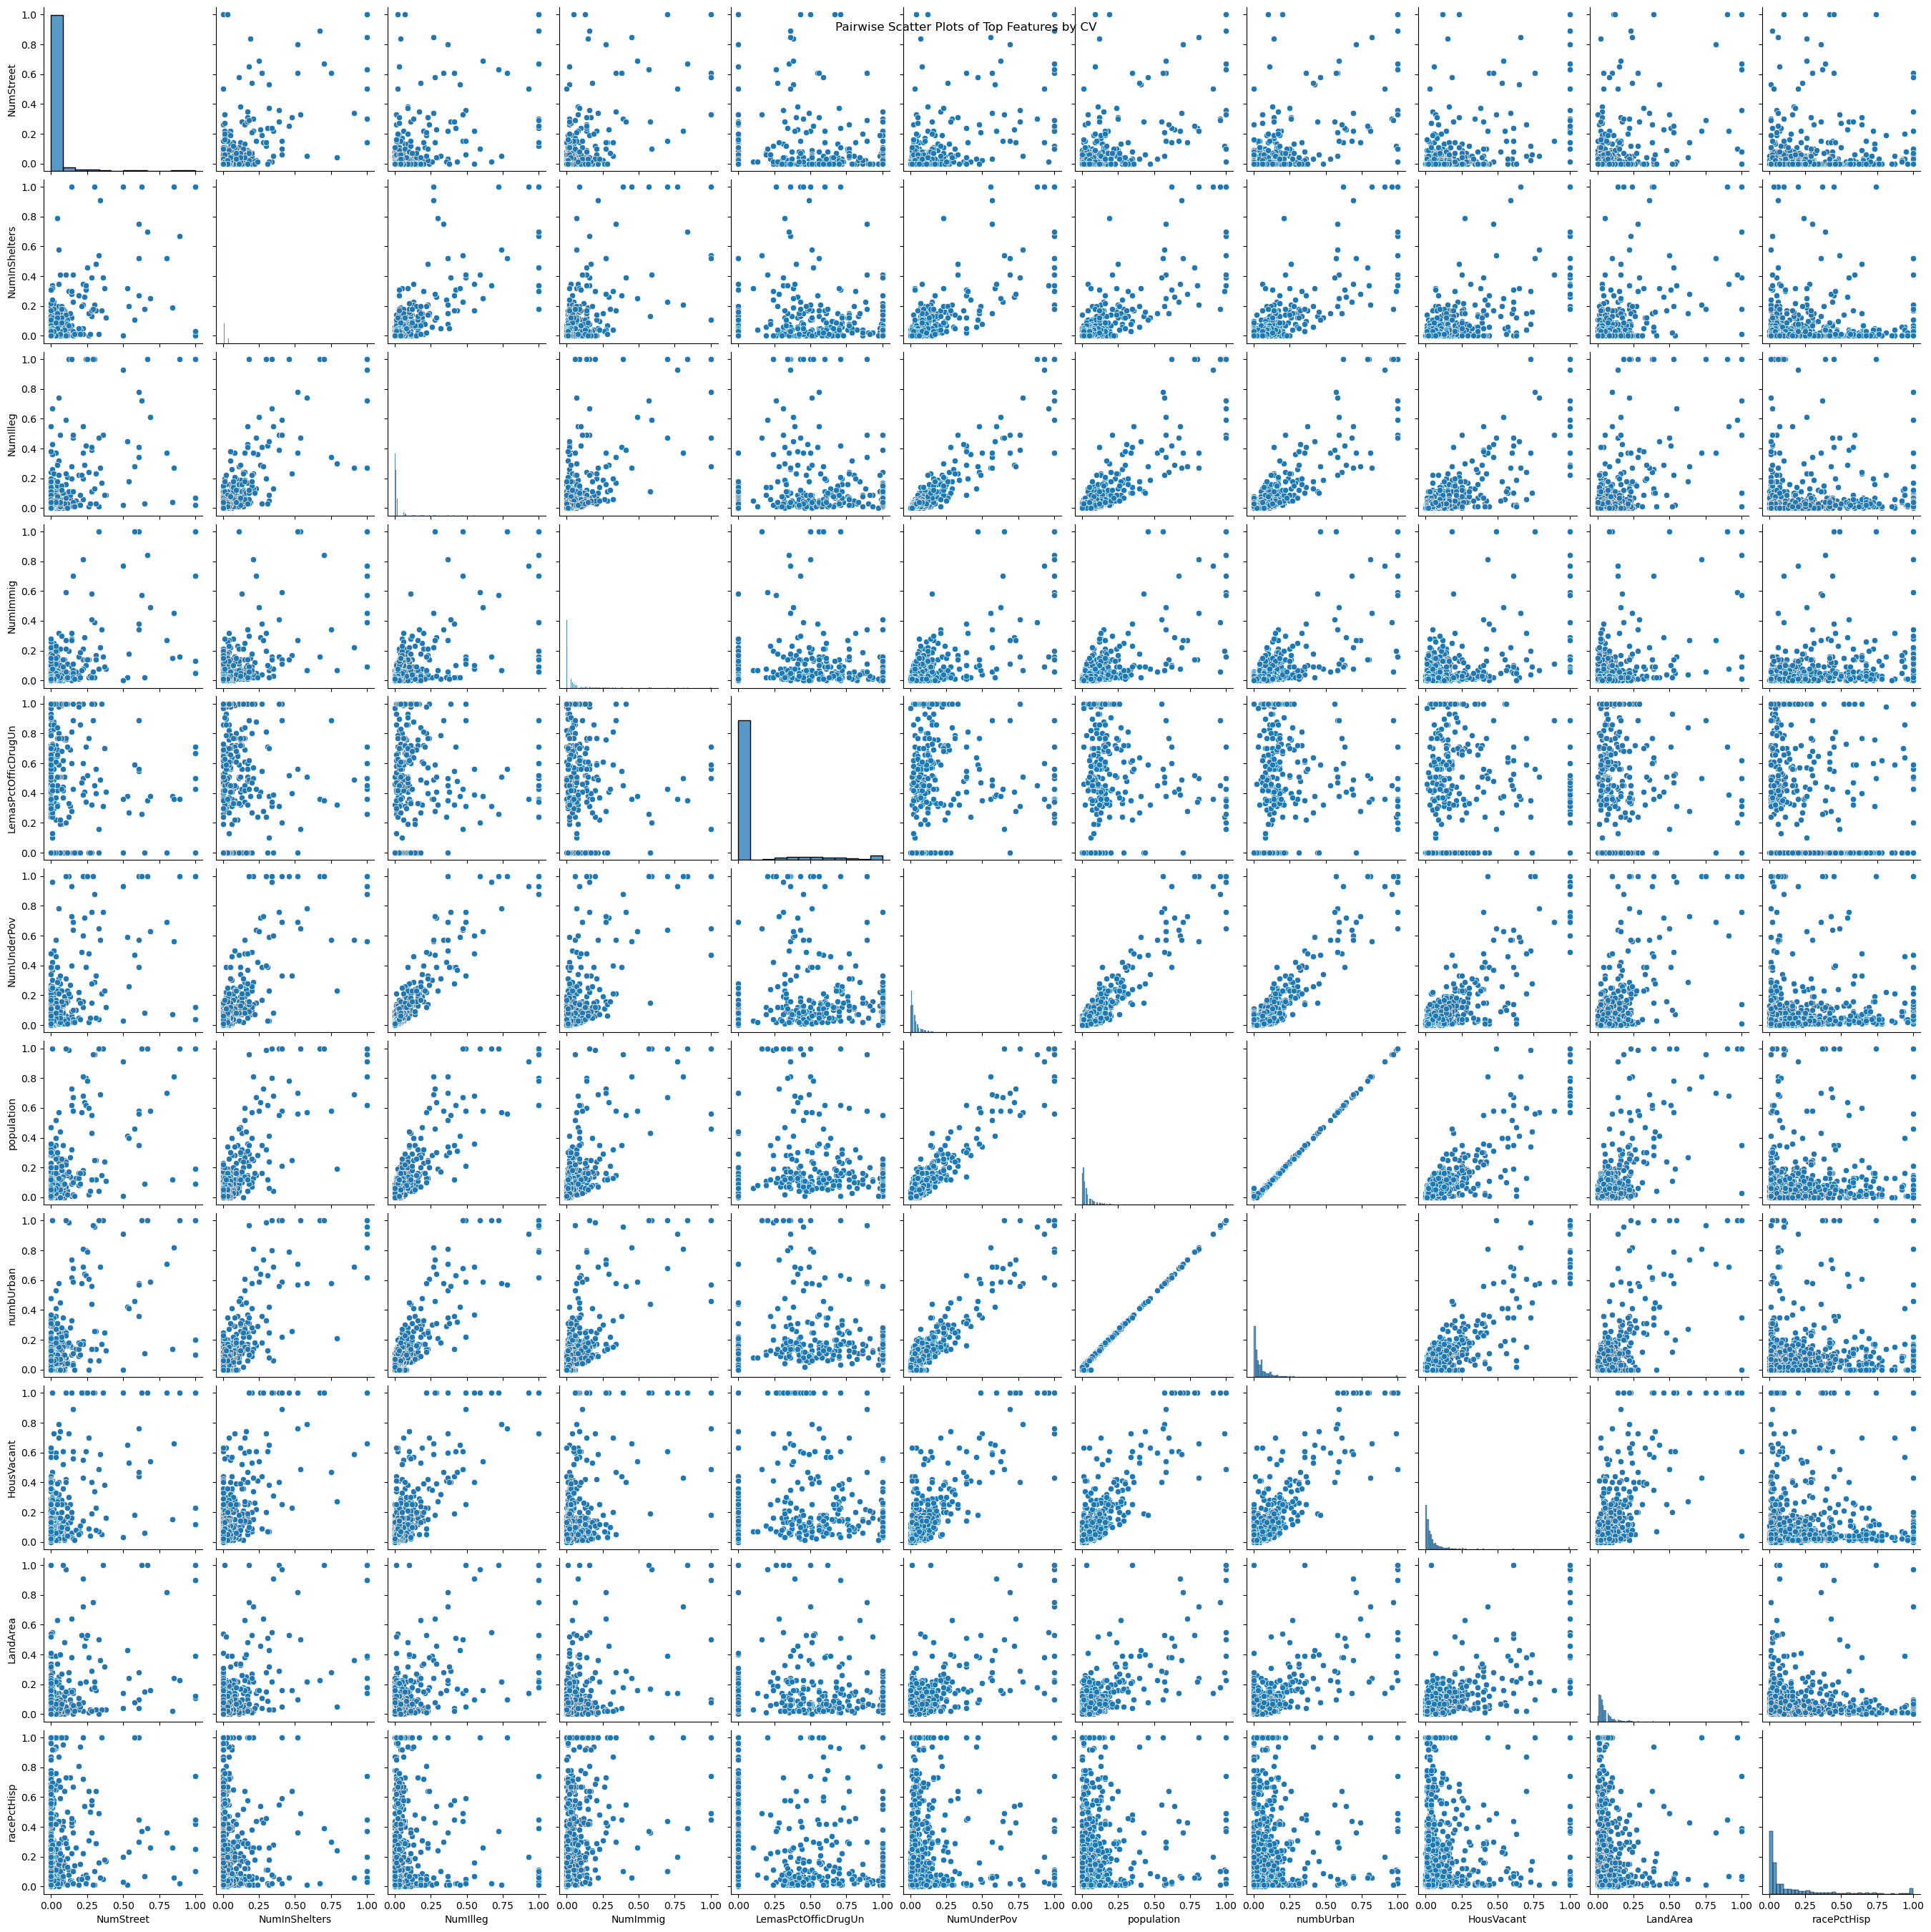

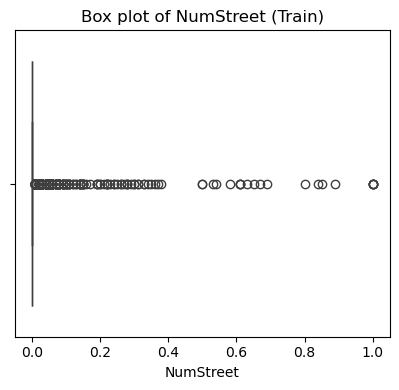

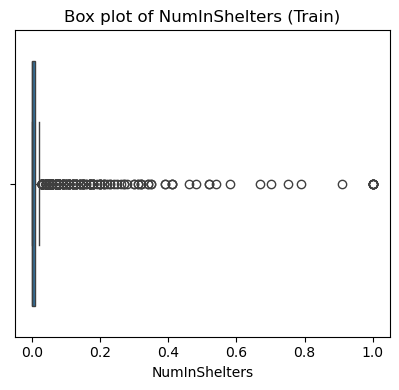

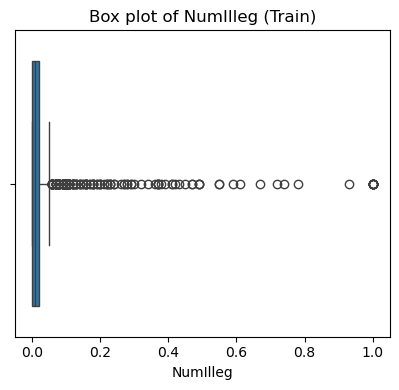

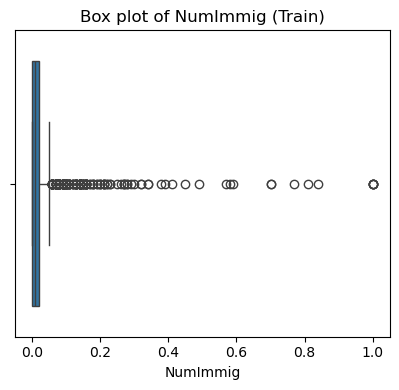

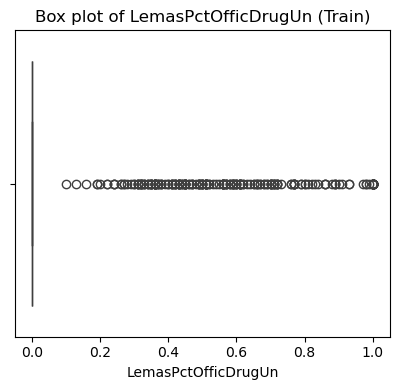

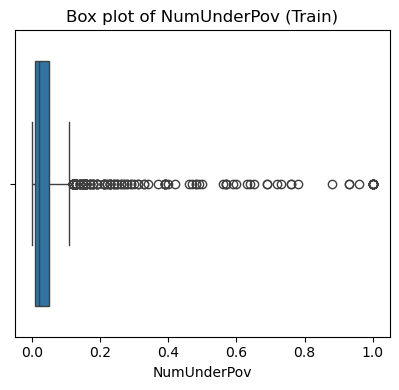

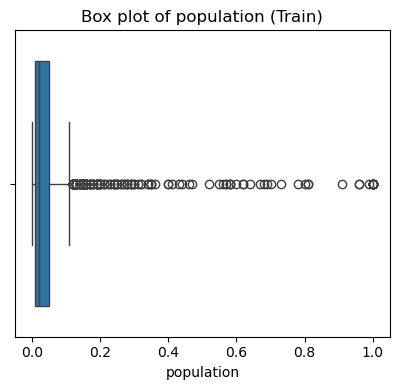

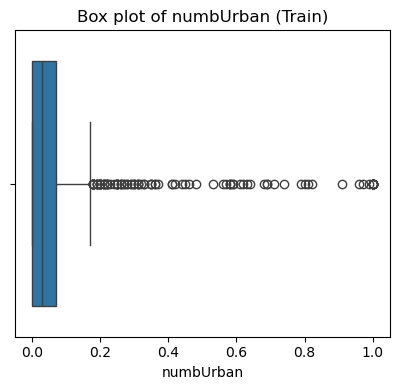

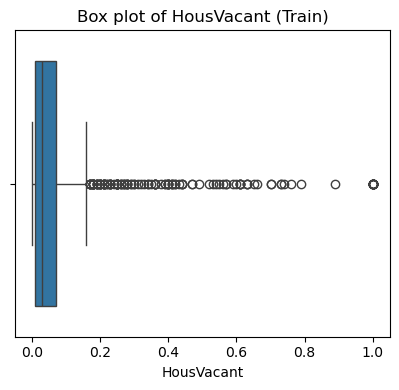

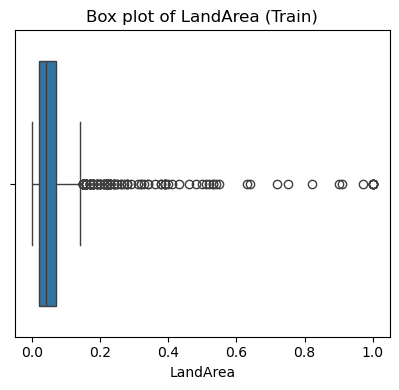

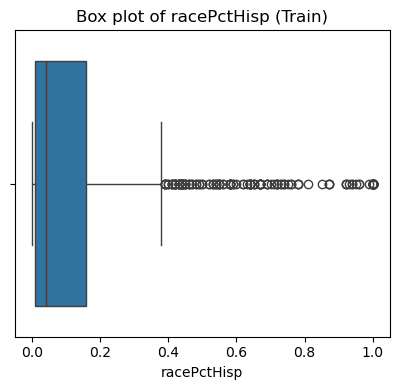

In [25]:
num_features = int(np.sqrt(128))

cv_train = train_df.std() / train_df.mean()
top_features_train = cv_train.nlargest(num_features).index

sns.pairplot(train_df[top_features_train])
plt.suptitle("Pairwise Scatter Plots of Top Features by CV")
plt.show()

for feature in top_features_train:
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 2)
    sns.boxplot(x=train_df[feature])
    plt.title(f'Box plot of {feature} (Train)')
    plt.tight_layout()
    plt.show()

From the scatter plots and box plots we can tell that features such as NumStreet and population, display high variability. Many features also show numerous outliers, which could influence model performance by introducing instabilities. Some features are heavily clustered around low values, with occasional high values creating distinct variability. Features like population and numbUrban show skewness where values are concentrated in lower ranges with occasional spikes.

All these observations suggest that these features hold valuable information that can enhance the model accuracy.

### (f) Fit a linear model

In [28]:
#Site reference

X_train = train_df.drop(columns=['ViolentCrimesPerPop'])
y_train = train_df['ViolentCrimesPerPop']
X_test = test_df.drop(columns=['ViolentCrimesPerPop'])
y_test = test_df['ViolentCrimesPerPop']

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

test_error = mean_squared_error(y_test, y_pred)
print("Test Error (MSE):", test_error)

Test Error (MSE): 0.01811246202653349


### (g) Fit a ridge regression model

In [30]:
# Site Reference

lambda_values = [0.1, 1, 10, 100, 1000]

ridge_model = RidgeCV(alphas=lambda_values, store_cv_values=True)
ridge_model.fit(X_train, y_train)

best_lambda = ridge_model.alpha_
print("Best alpha (lambda) chosen by cross-validation:", best_lambda)

y_pred_ridge = ridge_model.predict(X_test)

ridge_test_error = mean_squared_error(y_test, y_pred_ridge)
print("Test Error (MSE) for Ridge Regression:", ridge_test_error)

Best alpha (lambda) chosen by cross-validation: 1.0
Test Error (MSE) for Ridge Regression: 0.017723737122830298


### (h) Fit a LASSO model

In [32]:
# Site Reference

target_column = 'ViolentCrimesPerPop'

X_train = train_df.drop(columns=[target_column])
y_train = train_df[target_column]
X_test = test_df.drop(columns=[target_column])
y_test = test_df[target_column]

lasso_cv = LassoCV(cv=5, tol=1e-2, max_iter=20000).fit(X_train, y_train)
train_preds = lasso_cv.predict(X_train)
test_preds = lasso_cv.predict(X_test)
test_error_normalized = mean_squared_error(y_test, test_preds)

selected_features_normalized = X_train.columns[lasso_cv.coef_ != 0]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lasso_cv_standardized = LassoCV(cv=5).fit(X_train_scaled, y_train)
test_preds_standardized = lasso_cv_standardized.predict(X_test_scaled)
test_error_standardized = mean_squared_error(y_test, test_preds_standardized)

selected_features_standardized = X_train.columns[lasso_cv_standardized.coef_ != 0]

print("Test Error (Normalized):", test_error_normalized)
print("Test Error (Standardized):", test_error_standardized)

C:\Users\saipa\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:664: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.009826702372564, tolerance: 0.006746416078595318
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\saipa\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:664: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.010211306994712288, tolerance: 0.006746416078595318
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\saipa\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:664: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.009981166738072034, tolerance: 0.006746416078595318
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\saipa\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_des

Test Error (Normalized): 0.01775273493988063
Test Error (Standardized): 0.017807417896751887


### (i) Fit a PCR model

In [34]:
#Site & Chagpt reference

target_column = 'ViolentCrimesPerPop'
X_train = train_df.drop(columns=[target_column])
y_train = train_df[target_column]
X_test = test_df.drop(columns=[target_column])
y_test = test_df[target_column]

best_score = float('inf')
best_num_components = 0

for m in range(1, X_train.shape[1] + 1):
    pcr_pipeline = Pipeline([
        ('pca', PCA(n_components=m)),
        ('linear_regression', LinearRegression())
    ])
    
    scores = -cross_val_score(pcr_pipeline, X_train, y_train, 
                              cv=5, scoring='neg_mean_squared_error')
    mean_score = scores.mean()
    
    if mean_score < best_score:
        best_score = mean_score
        best_num_components = m

print(f"Optimal number of components: {best_num_components}")
print(f"Cross-validated train error: {best_score}")

pcr_pipeline = Pipeline([
    ('pca', PCA(n_components=best_num_components)),
    ('linear_regression', LinearRegression())
])

pcr_pipeline.fit(X_train, y_train)
test_preds = pcr_pipeline.predict(X_test)
test_error = mean_squared_error(y_test, test_preds)

print(f"Test error with PCR model: {test_error}")


Optimal number of components: 96
Cross-validated train error: 0.019408640644952842
Test error with PCR model: 0.01844549084081887


### (j) Fit a boosting tree

In [36]:
# Chatgpt reference

target_column = 'ViolentCrimesPerPop'
X_train = train_df.drop(columns=[target_column])
y_train = train_df[target_column]
X_test = test_df.drop(columns=[target_column])
y_test = test_df[target_column]

xgb_model = xgb.XGBRegressor(objective='reg:squarederror', booster='gbtree', n_estimators=100)

param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100],
    'learning_rate': [0.01, 0.1, 0.2], 
    'max_depth': [3, 5, 7]
}

grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
best_alpha = grid_search.best_params_['alpha']
print("Best alpha:", best_alpha)
print("Best cross-validated train error:", -grid_search.best_score_)

best_model.fit(X_train, y_train)
test_preds = best_model.predict(X_test)
test_error = mean_squared_error(y_test, test_preds)

print("Test error with L1-penalized gradient boosting tree:", test_error)

Best alpha: 1
Best cross-validated train error: 0.020344082766412936
Test error with L1-penalized gradient boosting tree: 0.016432788356071665


### Citations & References

1.(b). Took reference from Google:

https://scikit-learn.org/dev/modules/generated/sklearn.tree.DecisionTreeClassifier.html

1.(c). Took reference from the site provided:

https://www.kdnuggets.com/2017/05/simplifying-decision-tree-interpretation-decision-rules-python.html

1.(d). Took reference from Chatgpt:

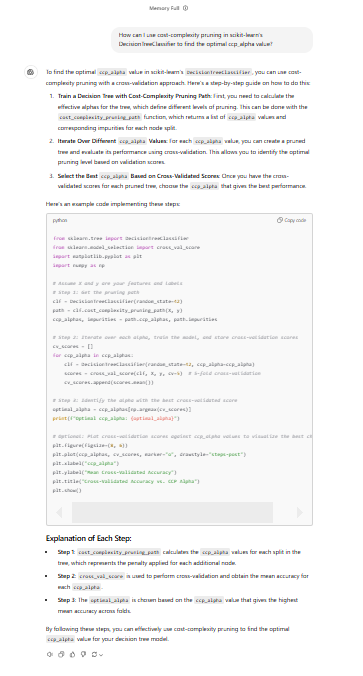

2.(b) Took reference from Google and Chatgpt:

https://datascience.stackexchange.com/questions/104510/drop-or-impute-the-missing-values
https://airbyte.com/data-engineering-resources/data-imputation

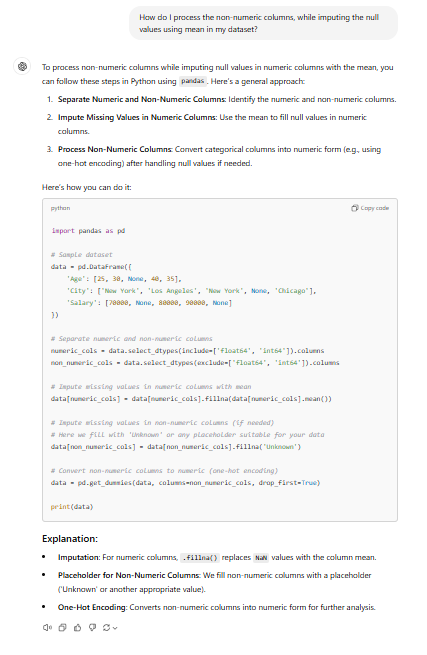

2.(c) Took reference from Google:

https://www.geeksforgeeks.org/plotting-correlation-matrix-using-python/
https://www.geeksforgeeks.org/how-to-create-a-seaborn-correlation-heatmap-in-python/

2.(d) https://www.statology.org/coefficient-of-variation-in-python/

2.(f)  Took reference from Google:

https://scikit-learn.org/1.5/modules/generated/sklearn.metrics.mean_squared_error.html

2.(g) Took reference from Google:

https://www.statology.org/ridge-regression-in-python/
https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.Ridge.html

2.(h) Took reference from Google:

https://www.geeksforgeeks.org/implementation-of-lasso-regression-from-scratch-using-python/
https://www.analyticsvidhya.com/blog/2016/01/ridge-lasso-regression-python-complete-tutorial/#:~:text=Gain%20practical%20experience%20in%20implementing,(lambda)%20in%20lasso%20regression.
https://www.kaggle.com/code/floser/aw6-the-lasso-cross-validated

2.(i) Took reference from Google and Chatgpt:

https://www.graphpad.com/guides/prism/latest/statistics/stat_pcr_overview.htm
https://www.statology.org/principal-components-regression-in-python/

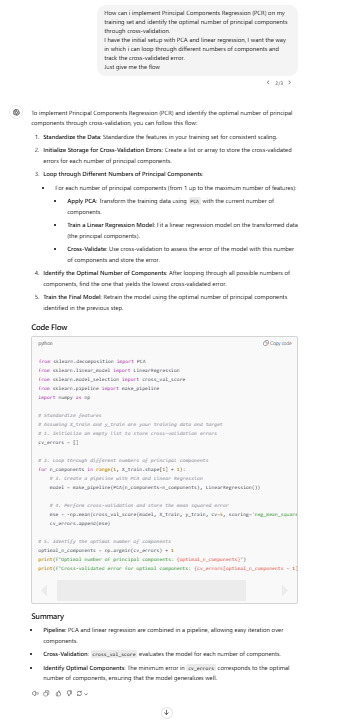

2.(j) Took reference from Chatgpt:

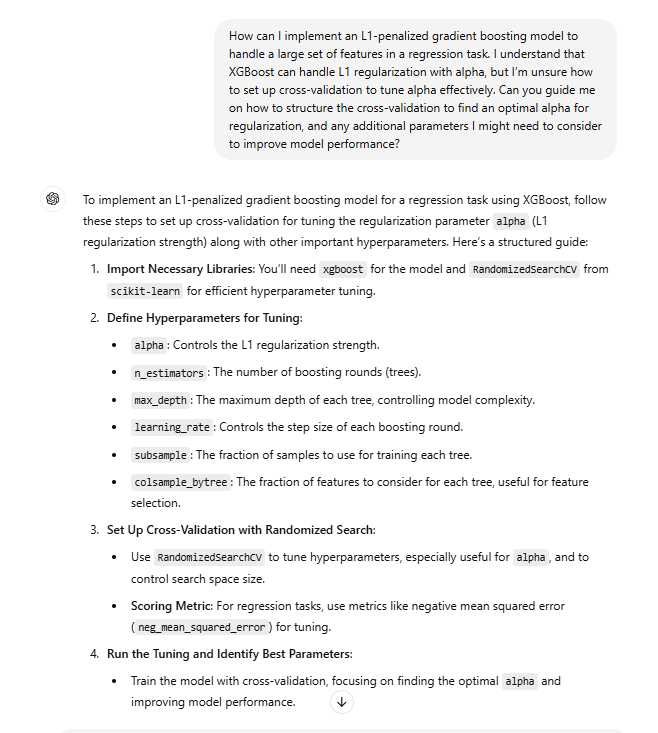